# 02 - Exploratory Data Analysis

**Central question: what is a news headline classifier actually learning?**

This notebook establishes whether Fox/NBC differences are driven by *topic coverage* (what they write about) or *writing style* (how they write). This distinction matters because:
- A topic-based classifier is brittle --> it will fail when both outlets cover the same story
- A style-based classifier generalizes --> stylistic conventions are relatively stable across the news cycle

The answer turns out to be: **both matter, but style persists even after controlling for topic**.

**Sections:**
1. Data loading and combination
2. Category extraction
3. Publication volume over time
4. Headline length distributions
5. Posting hour and day-of-week patterns
6. Punctuation and style signals
7. URL-extracted category distribution
8. BERTopic — outlet-agnostic topic modeling
9. Style signals within shared topics **(key finding)**
10. Save processed dataset

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

FOX_COLOR = '#E81B23'
NBC_COLOR = '#2A5EAC'
ALPHA = 0.75

## 1. Data Loading and Combination

In [11]:
fox = pd.read_csv('../data/raw/fox_scraped_all.csv')
nbc = pd.read_csv('../data/raw/nbc_scraped_all.csv')

print(f'Fox: {len(fox):,} rows | NBC: {len(nbc):,} rows')

Fox: 2,000 rows | NBC: 1,805 rows


## 2. Category Extraction

The scraped `topic` column contains article-level pills from the page (e.g., "Donald Trump", "POLITICS", "Israel"). There are 314 unique values and not a consistent taxonomy. Instead we extract the category from the URL path segment, which reflects each outlet's actual editorial sections.

In [12]:
# Fox: foxnews.com/<category>/...
threshold = 5
fox['category'] = fox['url'].str.extract(r'foxnews\.com/([^/]+)')
counts = fox['category'].value_counts()
fox['category'] = fox['category'].replace(counts[counts < threshold].index, 'other')

# NBC: nbcnews.com/<section>/ or nbcnews.com/news/<subsection>/
nbc_cat = nbc['url'].str.extract(r'nbcnews\.com/([^/]+)')[0]
nbc_sub = nbc['url'].str.extract(r'nbcnews\.com/news/([^/]+)')[0]
nbc['category'] = nbc_sub.where(nbc_cat == 'news', other=nbc_cat)

def clean_nbc_category(cat):
    if pd.isna(cat): return 'other'
    if len(cat) > 40 or cat.count('-') > 5: return 'other'  # slug artifacts
    return cat

nbc['category'] = nbc['category'].apply(clean_nbc_category)
preserve = {'nbc-out', 'nbcblk', 'latino', 'asian-america'}  # keep identity verticals
counts_nbc = nbc['category'].value_counts()
small = set(counts_nbc[counts_nbc < threshold].index) - preserve
nbc['category'] = nbc['category'].replace(list(small), 'other')

print('Fox categories:', fox['category'].nunique())
print(fox['category'].value_counts().to_string())
print('\nNBC categories:', nbc['category'].nunique())
print(nbc['category'].value_counts().to_string())

Fox categories: 15
category
politics          615
media             385
lifestyle         203
us                201
entertainment     166
world             110
sports             90
health             73
travel             41
opinion            39
food-drink         35
official-polls     14
tech               12
live-news          10
other               6

NBC categories: 18
category
politics          679
world             435
select            274
us-news            73
tech               68
latino             38
other              36
investigations     32
asian-america      27
science            27
health             26
nbc-out            19
nbcblk             17
pop-culture        15
weather            12
business           11
sports             10
meet-the-press      6


In [14]:
fox

,url,topic,title,subtitle,author,datetime_posted,label,category
0,https://www.foxnews.com/politics/blinken-meets...,Secretary of State,"Blinken meets Qatar PM, says Israeli actions a...",Blinken stressed the importance of protecting ...,Timothy H.J. Nerozzi,2023-10-13T14:06:08-04:00,Fox News,politics
1,https://www.foxnews.com/entertainment/bruce-wi...,Divorce,"Bruce Willis, Demi Moore avoided doing one thi...",Demi Moore and Bruce Willis have been divorced...,Lauryn Overhultz,2024-10-18T15:56:05-04:00,Fox News,entertainment
2,https://www.foxnews.com/media/the-view-co-host...,Media,"'The View' co-host, CNN commentator Ana Navarr...","'It’s just such a mind-blowing moment,' Navarr...",Kristine Parks,2024-08-19T21:00:35-04:00,Fox News,media
3,https://www.foxnews.com/entertainment/emily-bl...,Celebrity News,Emily Blunt says her ‘toes curl’ when people t...,Blunt and John Krasinski share two daughters; ...,Lauryn Overhultz,2023-06-09T13:55:28-04:00,Fox News,entertainment
4,https://www.foxnews.com/lifestyle/jack-carrs-e...,LIFESTYLE,Jack Carr recalls Gen. Eisenhower's D-Day memo...,Bestselling author recalls Gen. Eisenhower's s...,Jack Carr,2024-06-06T04:30:24-04:00,Fox News,lifestyle
...,...,...,...,...,...,...,...,...
1995,https://www.foxnews.com/official-polls/fox-new...,Fox News Poll,Fox News Poll: Harris tops Trump by two points,The latest Fox News national survey finds 3-po...,Dana Blanton,2024-09-18T18:00:01-04:00,Fox News,official-polls
1996,https://www.foxnews.com/politics/trump-harris-...,ECONOMY,"Trump, Harris blasted for ignoring exploding b...","""Both have left a lot of details unspecified,""...",Alec Schemmel,2024-09-29T04:00:27-04:00,Fox News,politics
1997,https://www.foxnews.com/world/biden-admin-outl...,Antisemitism Exposed,Biden admin outlaws Palestinian organization f...,Canada also listed Samidoun as 'a terrorist en...,Benjamin Weinthal,2024-10-16T15:12:35-04:00,Fox News,world
1998,https://www.foxnews.com/politics/kamala-harris...,Supreme Court,Flashback: Kamala Harris was open to packing S...,"'We have to take this challenge head-on, and e...",Fox News,2020-09-21T20:39:36-04:00,Fox News,politics


In [26]:
# Combine and encode label
news_data = pd.concat([fox, nbc], ignore_index=True)
news_data['datetime_posted'] = pd.to_datetime(news_data['datetime_posted'], format='mixed', utc=True)

df = news_data.drop(columns=['topic']).copy()
df['is_fox'] = (df['label'] == 'Fox News').astype(int)
df = df.drop(columns=['label'])

df['date'] = df['datetime_posted'].dt.date
df['year_month'] = df['datetime_posted'].dt.to_period('M')
df['hour'] = df['datetime_posted'].dt.hour
df['dow'] = df['datetime_posted'].dt.day_name()

fox_df = df[df['is_fox'] == 1].copy()
nbc_df = df[df['is_fox'] == 0].copy()

print(f'Fox: {len(fox_df):,} | NBC: {len(nbc_df):,}')
print(f'Date range: {df["datetime_posted"].min().date()} to {df["datetime_posted"].max().date()}')
print(f'Missing titles: {df["title"].isna().sum()}')
print(f'Missing datetimes: {df["datetime_posted"].isna().sum():,} ({df["datetime_posted"].isna().mean():.1%})')

Fox: 2,000 | NBC: 1,805
Date range: 2020-01-06 to 2026-04-07
Missing titles: 4
Missing datetimes: 94 (2.5%)


/var/folders/hz/qryn97wj0_d33crxxrwm28t80000gn/T/ipykernel_13105/1701644085.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['datetime_posted'].dt.to_period('M')


## 3. Publication Volume Over Time

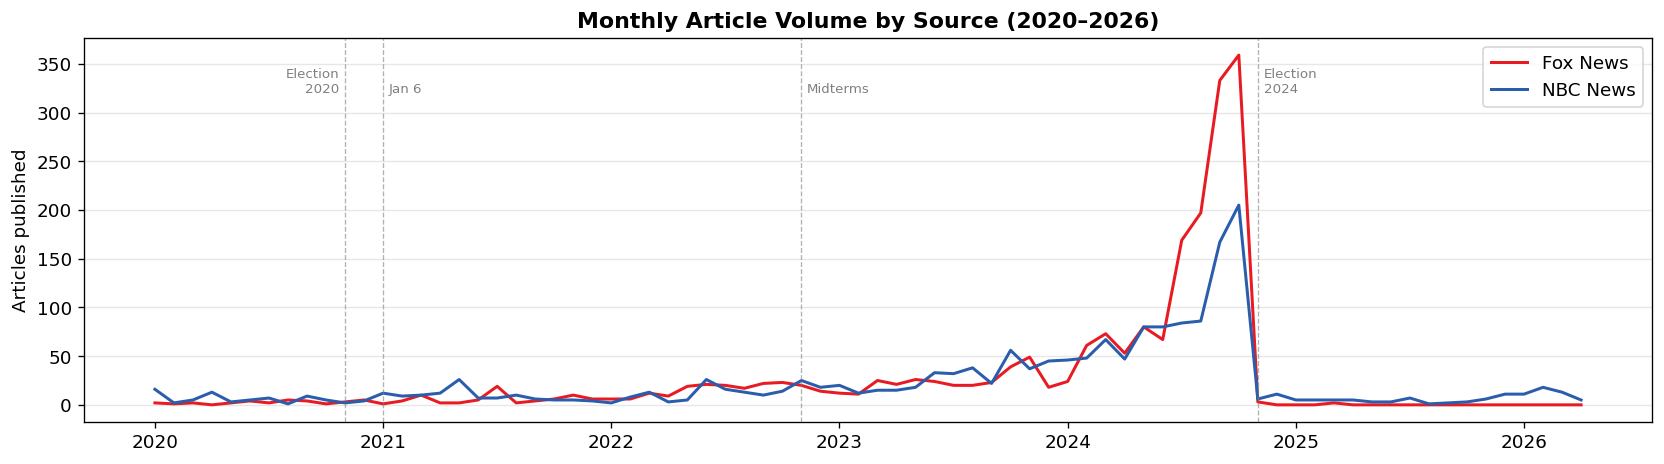

In [37]:
df_t  = df.dropna(subset=['datetime_posted'])
fox_t = df_t[df_t['is_fox'] == 1]
nbc_t = df_t[df_t['is_fox'] == 0]

fox_monthly = fox_t.groupby('year_month').size()
nbc_monthly = nbc_t.groupby('year_month').size()

all_periods = fox_monthly.index.union(nbc_monthly.index)
fox_monthly = fox_monthly.reindex(all_periods, fill_value=0)
nbc_monthly = nbc_monthly.reindex(all_periods, fill_value=0)

x = range(len(all_periods))
x_labels = [str(p) for p in all_periods]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(x, fox_monthly.values, color=FOX_COLOR, label='Fox News', linewidth=1.8)
ax.plot(x, nbc_monthly.values, color=NBC_COLOR, label='NBC News', linewidth=1.8)

events = {'2020-11': 'Election\n2020', '2021-01': 'Jan 6',
          '2022-11': 'Midterms', '2024-11': 'Election\n2024'}

for period_str, label in events.items():
    matches = [i for i, p in enumerate(x_labels) if p == period_str]
    if matches:
        if label == 'Election\n2020':
            ax.axvline(matches[0], color = 'gray', linestyle = '--', linewidth = 0.8, alpha = 0.6)
            ax.text(matches[0] - 0.3, ax.get_ylim()[1] * 0.85, label, fontsize = 8, color = 'gray', ha = 'right')
        
        else:
            ax.axvline(matches[0], color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
            ax.text(matches[0] + 0.3, ax.get_ylim()[1] * 0.85, label, fontsize=8, color='gray')

year_ticks  = [i for i, p in enumerate(x_labels) if p.endswith('-01')]
year_labels = [p[:4] for p in x_labels if p.endswith('-01')]
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels)
ax.set_title('Monthly Article Volume by Source (2020–2026)', fontweight='bold')
ax.set_ylabel('Articles published')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

os.makedirs("../figures", exist_ok = True)
plt.savefig('../figures/volume_over_time.png', dpi=150, bbox_inches='tight')

plt.show()

## 4. Headline Length Distributions

Fox headlines are consistently longer: median 14 words vs NBC's 12, mean 88.7 characters vs 73.7. This is one of the strongest and most consistent style signals in the dataset.

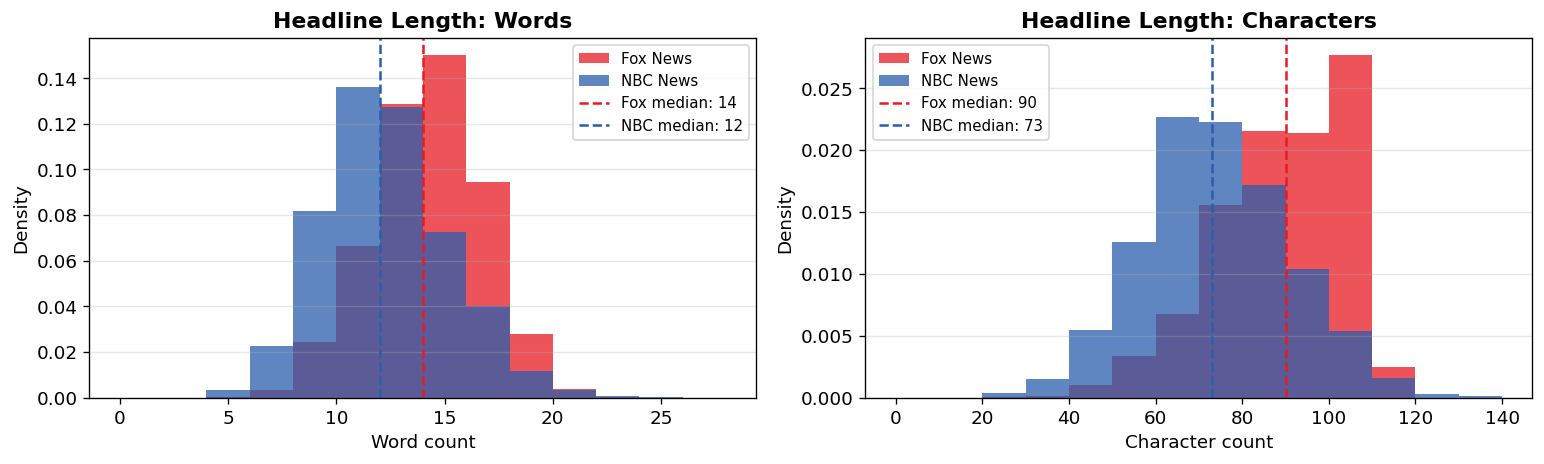

Summary stats:

word_count:
         count  mean  std  min   25%   50%   75%   max
is_fox                                                
0       1801.0  11.8  2.9  4.0  10.0  12.0  14.0  24.0
1       2000.0  13.8  2.6  5.0  12.0  14.0  16.0  22.0

char_count:
         count  mean   std   min   25%   50%    75%    max
is_fox                                                    
0       1801.0  73.7  17.2  21.0  62.0  73.0   85.0  139.0
1       2000.0  88.7  15.1  29.0  78.0  90.0  102.0  110.0


In [38]:
df_h = df.dropna(subset=['title']).copy()

df_h['word_count'] = df_h['title'].str.split().str.len()
df_h['char_count'] = df_h['title'].str.len()

fox_h = df_h[df_h['is_fox'] == 1]
nbc_h = df_h[df_h['is_fox'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label in zip(axes, ['word_count', 'char_count'], ['Word count', 'Character count']):
    
    bins = range(0, int(df_h[col].max()) + 5, 2 if col == 'word_count' else 10)
    ax.hist(fox_h[col], bins=bins, color=FOX_COLOR, alpha=ALPHA, label='Fox News', density=True)
    ax.hist(nbc_h[col], bins=bins, color=NBC_COLOR, alpha=ALPHA, label='NBC News', density=True)
    
    ax.axvline(fox_h[col].median(), color=FOX_COLOR, linestyle='--', linewidth=1.5,
               label=f'Fox median: {fox_h[col].median():.0f}')
    ax.axvline(nbc_h[col].median(), color=NBC_COLOR, linestyle='--', linewidth=1.5,
               label=f'NBC median: {nbc_h[col].median():.0f}')
    
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_title('Headline Length: Words', fontweight='bold')
axes[1].set_title('Headline Length: Characters', fontweight='bold')

plt.tight_layout()

os.makedirs("../figures", exist_ok = True)
plt.savefig('../figures/headline_length.png', dpi=150, bbox_inches='tight')

plt.show()

print('Summary stats:')
for col in ['word_count', 'char_count']:
    print(f'\n{col}:')
    print(df_h.groupby('is_fox')[col].describe().round(1).to_string())

## 5. Posting Hour and Day-of-Week Patterns

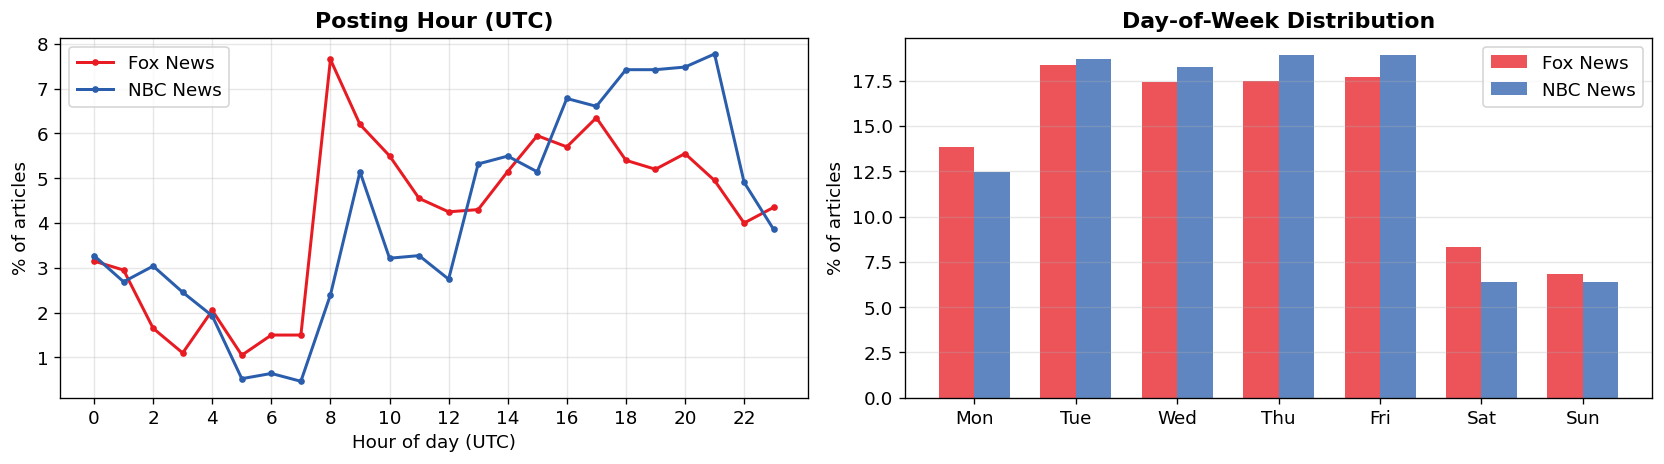

In [40]:
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fox_hour = fox_t.groupby('hour').size() / len(fox_t) * 100
nbc_hour = nbc_t.groupby('hour').size() / len(nbc_t) * 100

fox_dow  = fox_t['dow'].value_counts().reindex(DOW_ORDER) / len(fox_t) * 100
nbc_dow  = nbc_t['dow'].value_counts().reindex(DOW_ORDER) / len(nbc_t) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(fox_hour.index, fox_hour.values, color=FOX_COLOR, label='Fox News', linewidth=1.8, marker='o', markersize=3)
ax.plot(nbc_hour.index, nbc_hour.values, color=NBC_COLOR, label='NBC News', linewidth=1.8, marker='o', markersize=3)
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('% of articles')
ax.set_title('Posting Hour (UTC)', fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
x = np.arange(len(DOW_ORDER))
width = 0.35
ax.bar(x - width/2, fox_dow.values, width, color=FOX_COLOR, alpha=ALPHA, label='Fox News')
ax.bar(x + width/2, nbc_dow.values, width, color=NBC_COLOR, alpha=ALPHA, label='NBC News')
ax.set_xticks(x)
ax.set_xticklabels([d[:3] for d in DOW_ORDER])
ax.set_ylabel('% of articles')
ax.set_title('Day-of-Week Distribution', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

os.makedirs("../figures", exist_ok = True)
plt.savefig('../figures/posting_time.png', dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()

## 6. Punctuation and Style Signals

Fox News is known for editorializing with scare quotes (e.g., the `'crisis'`, `'expert'` framing). These are style signals the classifier may exploit independently of topic content.

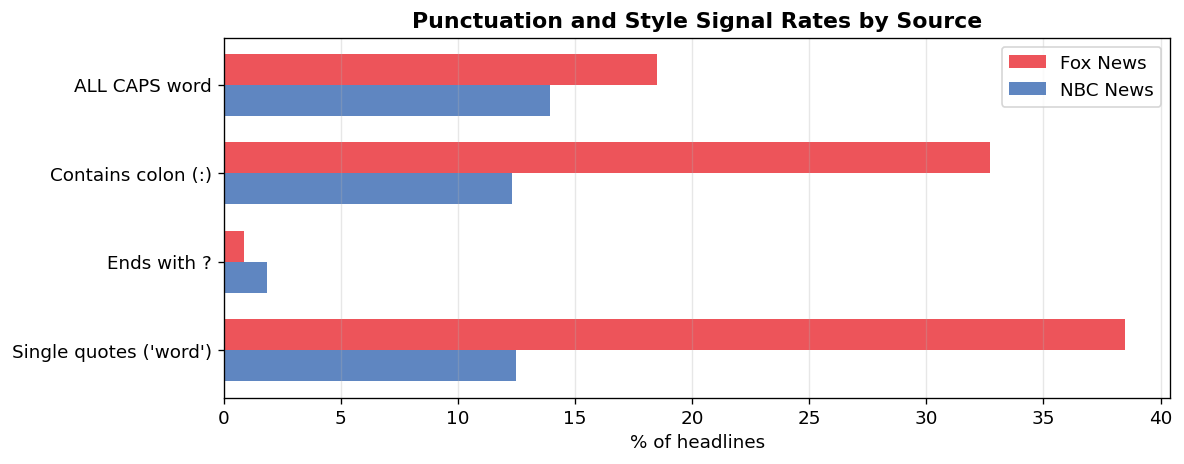

                        Fox News  NBC News
Single quotes ('word')      38.5      12.5
Ends with ?                  0.8       1.8
Contains colon (:)          32.7      12.3
ALL CAPS word               18.5      13.9


In [41]:
df_s = df.dropna(subset=['title']).copy()

df_s['word_count'] = df_s['title'].str.split().str.len()
df_s['char_count'] = df_s['title'].str.len()
df_s['has_single_quotes'] = df_s['title'].str.contains(r"'[^']{1,40}'", regex=True)
df_s['has_question'] = df_s['title'].str.endswith('?')
df_s['has_colon'] = df_s['title'].str.contains(':', regex=False)
df_s['has_allcaps'] = df_s['title'].str.contains(r'\b[A-Z]{3,}\b', regex=True)

style_cols = {
    'has_single_quotes': "Single quotes ('word')",
    'has_question': 'Ends with ?',
    'has_colon': 'Contains colon (:)',
    'has_allcaps': 'ALL CAPS word',
}

rates = pd.DataFrame({
    'Fox News': [df_s[df_s['is_fox']==1][c].mean()*100 for c in style_cols],
    'NBC News': [df_s[df_s['is_fox']==0][c].mean()*100 for c in style_cols],
}, index=style_cols.values())

fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(rates))
width = 0.35

ax.barh(x + width/2, rates['Fox News'], width, color=FOX_COLOR, alpha=ALPHA, label='Fox News')
ax.barh(x - width/2, rates['NBC News'], width, color=NBC_COLOR, alpha=ALPHA, label='NBC News')

ax.set_yticks(x)
ax.set_yticklabels(rates.index)

ax.set_xlabel('% of headlines')
ax.set_title('Punctuation and Style Signal Rates by Source', fontweight='bold')

ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()

os.makedirs("../figures", exist_ok = True)
plt.savefig('../figures/style_signals.png', dpi=150, bbox_inches='tight')

plt.show()

print(rates.round(1).to_string())

In [42]:
# Spot-check: confirm Fox single quotes are editorial, NBC are attribution
print('=== Fox single-quote examples ===')
for t in df_s[(df_s['is_fox']==1) & (df_s['has_single_quotes'])]['title'].sample(5, random_state=42):
    print(' ', t)

print('\n=== NBC single-quote examples ===')
for t in df_s[(df_s['is_fox']==0) & (df_s['has_single_quotes'])]['title'].sample(5, random_state=42):
    print(' ', t)

=== Fox single-quote examples ===
  Kirby slams Hamas chief Sinwar as 'the major obstacle' to cease-fire, hostage release deal with Israel
  Brian Stelter defends 2020 media coverage of Hunter Biden laptop story: We never labeled it 'disinformation'
  Major CNN Trump critic Brian Stelter admits Trump 'was funny' during Al Smith Dinner: 'A few great jokes'
  'Biggest medical fraud of our time': Riley Gaines dives into the heart of gender-affirming care epidemic
  Left 'just died' with the emergence of 'Kamala Harris Democrats,' says CNN's Van Jones

=== NBC single-quote examples ===
  'They're not here to hurt me': Former aide says Trump knew Jan. 6 crowd was armed
  Israeli forces begin 'targeted' ground operation in Lebanon, IDF says
  How 'sex addiction' has historically been used to absolve white men
  Stewart Rhodes wrote message to Trump after Jan. 6 calling on him to 'save the Republic' and arrest members of Congress
  Inside Egypt's 3,000-year-old 'lost golden city'


## 7. URL-Extracted Category Distribution

We examine how each news outlet distributes news stories across their editorial categories. An important note: cross-outlet comparisons are limited because Fox has `media`, `lifestyle`, and `entertainment` sections with no NBC equivalent, and NBC has `select` (product reviews) and `us-news` with no Fox equivalent. We address this in section 8 addresses this with outlet-agnostic topic modeling.

In [43]:
fox_cat_pct = fox_df['category'].value_counts(normalize=True) * 100
nbc_cat_pct = nbc_df['category'].value_counts(normalize=True) * 100

all_cats = sorted(set(fox_cat_pct.index) | set(nbc_cat_pct.index))
fox_vals = [fox_cat_pct.get(c, 0) for c in all_cats]
nbc_vals = [nbc_cat_pct.get(c, 0) for c in all_cats]

order    = sorted(range(len(all_cats)), key=lambda i: fox_vals[i], reverse=True)
all_cats = [all_cats[i] for i in order]
fox_vals = [fox_vals[i] for i in order]
nbc_vals = [nbc_vals[i] for i in order]

cat_df = pd.DataFrame({'fox_pct': fox_vals, 'nbc_pct': nbc_vals}, index=all_cats)
cat_df['divergence'] = (cat_df['fox_pct'] - cat_df['nbc_pct']).abs()

print('Most divergent categories:')
print(cat_df.sort_values('divergence', ascending=False).head(10).round(1).to_string())
print('\nFox-only categories:')
print(cat_df[cat_df['nbc_pct'] == 0].round(1).to_string())
print('\nNBC-only categories:')
print(cat_df[cat_df['fox_pct'] == 0].round(1).to_string())

Most divergent categories:
               fox_pct  nbc_pct  divergence
media             19.2      0.0        19.2
world              5.5     24.1        18.6
select             0.0     15.2        15.2
lifestyle         10.2      0.0        10.2
us                10.0      0.0        10.0
entertainment      8.3      0.0         8.3
politics          30.8     37.6         6.9
us-news            0.0      4.0         4.0
sports             4.5      0.6         3.9
tech               0.6      3.8         3.2

Fox-only categories:
                fox_pct  nbc_pct  divergence
media              19.2      0.0        19.2
lifestyle          10.2      0.0        10.2
us                 10.0      0.0        10.0
entertainment       8.3      0.0         8.3
travel              2.1      0.0         2.1
opinion             2.0      0.0         2.0
food-drink          1.8      0.0         1.8
official-polls      0.7      0.0         0.7
live-news           0.5      0.0         0.5

NBC-only categor

## 8 — BERTopic: Outlet-Agnostic Topic Modeling

URL categories reflect each outlet's *own* editorial taxonomy. BERTopic assigns topic labels from the headline text itself. Both outlets receive labels from the same neutral system, enabling fair cross-outlet topic comparisons.

**Pipeline:** MiniLM embeddings → UMAP (5 dims) → HDBSCAN clustering → c-TF-IDF labels.

In [44]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer

df_bert    = df.dropna(subset=['title']).copy()
headlines  = df_bert['title'].tolist()

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Pre-compute embeddings to avoid recomputation during hyperparameter search
embeddings = embedding_model.encode(headlines, show_progress_bar=True)
print(f'Embeddings shape: {embeddings.shape}')

/Users/rohankrishnan/Documents/GitHub/cis-5190-news/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 119/119 [00:02<00:00, 42.23it/s]


Embeddings shape: (3801, 384)


In [45]:
# n_components=5 chosen after testing 3, 5, 8, 10:
# n=5 gives 13 topics with 23% outliers — best balance of specificity and coverage
umap_model   = UMAP(n_components=5, random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=30, prediction_data=True)
topic_model  = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics='auto',
    verbose=True
)

topics, probs = topic_model.fit_transform(headlines, embeddings)

print('\nTopic info:')
print(topic_model.get_topic_info()[['Topic', 'Count', 'Name', 'Representation']].to_string())

2026-05-05 18:50:08,512 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-05 18:50:18,985 - BERTopic - Dimensionality - Completed ✓
2026-05-05 18:50:18,986 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-05 18:50:19,043 - BERTopic - Cluster - Completed ✓
2026-05-05 18:50:19,043 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-05 18:50:19,068 - BERTopic - Representation - Completed ✓
2026-05-05 18:50:19,068 - BERTopic - Topic reduction - Reducing number of topics
2026-05-05 18:50:19,071 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-05 18:50:19,093 - BERTopic - Representation - Completed ✓
2026-05-05 18:50:19,094 - BERTopic - Topic reduction - Reduced number of topics from 14 to 14



Topic info:
    Topic  Count                              Name                                                                        Representation
0      -1    877                   -1_to_in_the_of                                     [to, in, the, of, on, for, trump, and, as, after]
1       0    762       0_harris_trump_kamala_biden                              [harris, trump, kamala, biden, to, in, the, on, for, of]
2       1    598       1_israel_hamas_gaza_israeli                      [israel, hamas, gaza, israeli, in, of, netanyahu, to, iran, and]
3       2    347      2_best_2026_select_according                      [best, 2026, select, according, nbc, the, to, experts, for, and]
4       3    334    3_trump_jan_assassination_case            [trump, jan, assassination, case, capitol, court, attempt, judge, to, who]
5       4    154       4_taylor_swift_willis_bruce                 [taylor, swift, willis, bruce, with, after, his, cowell, simon, liam]
6       5    137        5_ru

In [46]:
# Assign human-readable labels (based on keyword inspection above)
topic_labels = {
    -1: 'Outlier',
     0: 'US Politics / Election',
     1: 'Israel-Gaza Conflict',
     2: 'NBC Select (Product Reviews)',
     3: 'Trump Legal / Jan 6 / Assassination Attempt',
     4: 'Entertainment / Celebrity News',
     5: 'Russia / Ukraine / China',
     6: 'Crime / Immigration',
     7: 'Fox: History Series',
     8: 'Abortion / Reproductive Rights',
     9: 'Fox: Transgender Sports',
    10: 'Hurricanes / Weather',
    11: 'Fox: Health Studies',
    12: 'Fox: Biden Climate Policy',
}

df_bert['topic_id'] = topics
df_bert['topic_label'] = df_bert['topic_id'].map(topic_labels)

# Distribution by source
check = df_bert.groupby(['topic_id', 'is_fox']).size().unstack(fill_value=0)
check.columns = ['NBC', 'Fox']
check['fox_pct'] = (check['Fox'] / (check['Fox'] + check['NBC']) * 100).round(1)
print(check)

          NBC  Fox  fox_pct
topic_id                   
-1        377  500     57.0
 0        219  543     71.3
 1        432  166     27.8
 2        279   68     19.6
 3        215  119     35.6
 4         22  132     85.7
 5        113   24     17.5
 6         37   93     71.5
 7          1  125     99.2
 8         54   42     43.8
 9          8   67     89.3
 10        39   32     45.1
 11         2   46     95.8
 12         3   43     93.5


In [47]:
# Source distribution across topics (normalized)
df_topics  = df_bert[df_bert['topic_id'] != -1].copy()
topic_dist = df_topics.groupby(['topic_label', 'is_fox']).size().unstack(fill_value=0)
topic_dist.columns = ['NBC News', 'Fox News']

topic_dist['NBC_pct']    = topic_dist['NBC News'] / topic_dist['NBC News'].sum() * 100
topic_dist['Fox_pct']    = topic_dist['Fox News'] / topic_dist['Fox News'].sum() * 100
topic_dist['divergence'] = (topic_dist['Fox_pct'] - topic_dist['NBC_pct']).abs()

print(topic_dist.sort_values('divergence', ascending=False).round(1).to_string())

                                             NBC News  Fox News  NBC_pct  Fox_pct  divergence
topic_label                                                                                  
US Politics / Election                            219       543     15.4     36.2        20.8
Israel-Gaza Conflict                              432       166     30.3     11.1        19.3
NBC Select (Product Reviews)                      279        68     19.6      4.5        15.1
Fox: History Series                                 1       125      0.1      8.3         8.3
Entertainment / Celebrity News                     22       132      1.5      8.8         7.3
Trump Legal / Jan 6 / Assassination Attempt       215       119     15.1      7.9         7.2
Russia / Ukraine / China                          113        24      7.9      1.6         6.3
Fox: Transgender Sports                             8        67      0.6      4.5         3.9
Crime / Immigration                                37       

## 9. Style Signals Within Shared Topics (Key Finding)

**Our main test:** even when Fox and NBC cover the *same* BERTopic-assigned subject matter, do stylistic differences persist? If yes, a classifier trained on headlines is learning style, not just topic.

We restrict to topics with >10 articles from each outlet so comparisons are meaningful.

In [48]:
# Merge topic labels into the style dataframe
df_s1 = df_s.merge(df_bert[['url', 'topic_id', 'topic_label']], on='url', how='left')

# Keep only shared topics
topic_counts  = df_topics.groupby(['topic_label', 'is_fox']).size().unstack(fill_value=0)
topic_counts.columns = ['NBC', 'Fox']
shared_topics = topic_counts[(topic_counts['NBC'] > 10) & (topic_counts['Fox'] > 10)].index.tolist()
print('Shared topics (both outlets > 10 articles):', shared_topics)

df_shared = df_s1[df_s1['topic_label'].isin(shared_topics)].copy()

style_by_topic = df_shared.groupby(['topic_label', 'is_fox']).agg(
    n=('title', 'count'),
    avg_words=('word_count', 'mean'),
    pct_single_quotes=('has_single_quotes', 'mean'),
    pct_question=('has_question', 'mean'),
    pct_colon=('has_colon', 'mean'),
).round(3)

print('\nStyle signals within shared topics (Fox is_fox=1, NBC is_fox=0):')
print(style_by_topic.to_string())

Shared topics (both outlets > 10 articles): ['Abortion / Reproductive Rights', 'Crime / Immigration', 'Entertainment / Celebrity News', 'Hurricanes / Weather', 'Israel-Gaza Conflict', 'NBC Select (Product Reviews)', 'Russia / Ukraine / China', 'Trump Legal / Jan 6 / Assassination Attempt', 'US Politics / Election']

Style signals within shared topics (Fox is_fox=1, NBC is_fox=0):
                                                      n  avg_words  pct_single_quotes  pct_question  pct_colon
topic_label                                 is_fox                                                            
Abortion / Reproductive Rights              0        54     11.907              0.111         0.000      0.111
                                            1        42     13.405              0.429         0.000      0.262
Crime / Immigration                         0        37     13.486              0.162         0.000      0.081
                                            1        93     13

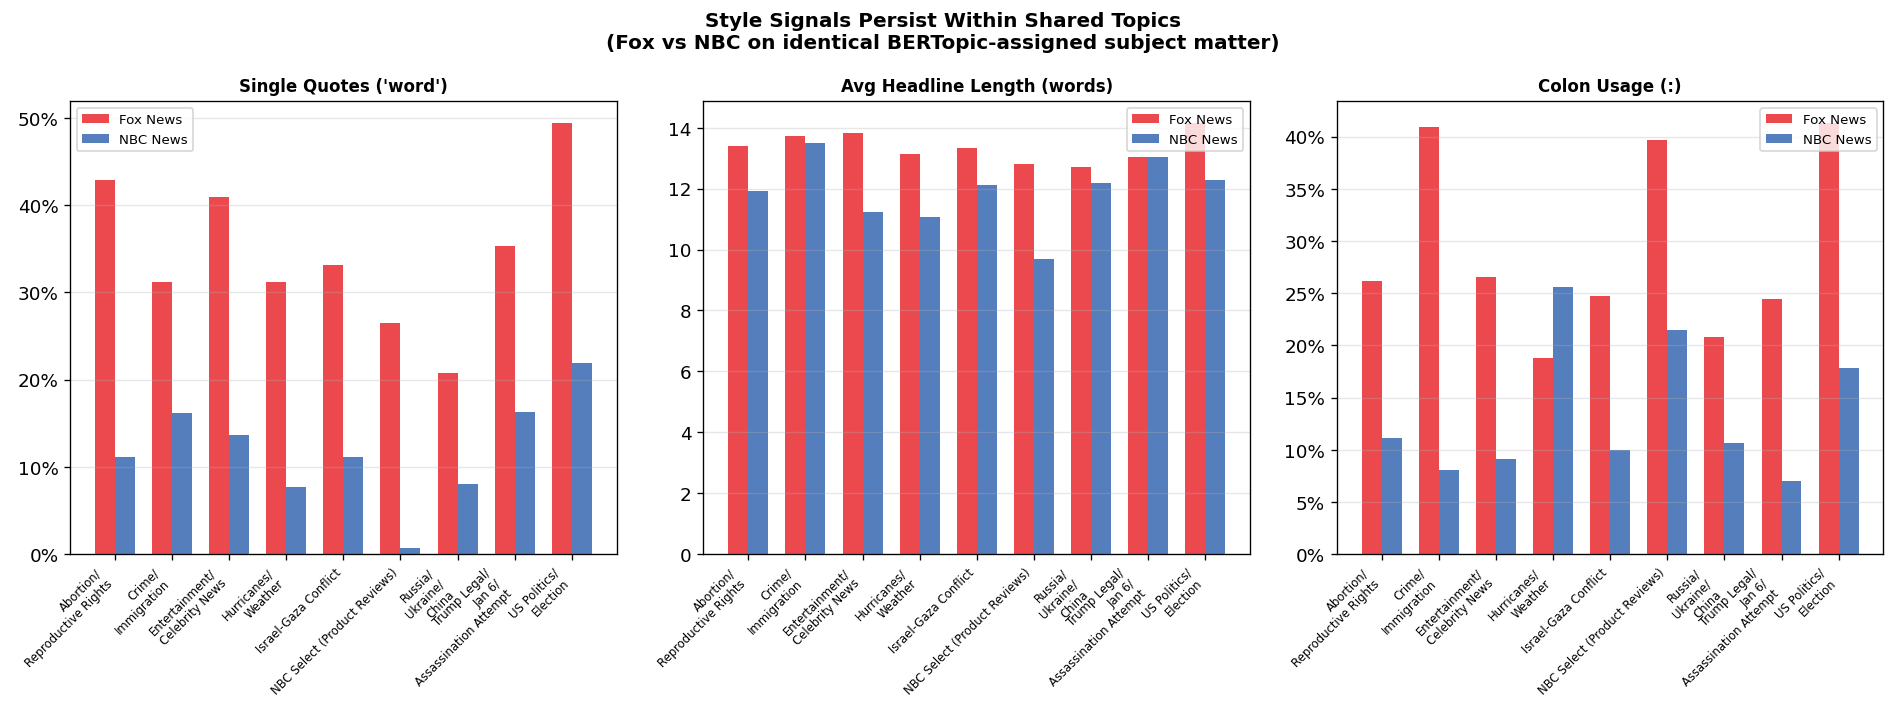


KEY FINDING: Fox single-quote rates are higher than NBC in EVERY shared topic.
This is evidence that the classifier is learning style, not just topic coverage.


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metrics = {
    'pct_single_quotes': "Single Quotes ('word')",
    'avg_words': 'Avg Headline Length (words)',
    'pct_colon': 'Colon Usage (:)',
}

short_labels = [t.replace(' / ', '/\n') for t in shared_topics]

for ax, (metric, metric_label) in zip(axes, metrics.items()):
    fox_vals = [style_by_topic.loc[(t, 1), metric] for t in shared_topics]
    nbc_vals = [style_by_topic.loc[(t, 0), metric] for t in shared_topics]
    
    x = np.arange(len(shared_topics))
    width = 0.35
    
    ax.bar(x - width/2, fox_vals, width, color=FOX_COLOR, alpha=0.8, label='Fox News')
    ax.bar(x + width/2, nbc_vals, width, color=NBC_COLOR, alpha=0.8, label='NBC News')
    
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=7, rotation=45, ha='right')
    
    ax.set_title(metric_label, fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)
    
    if metric in ['pct_single_quotes', 'pct_colon']:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))

fig.suptitle(
    'Style Signals Persist Within Shared Topics\n'
    '(Fox vs NBC on identical BERTopic-assigned subject matter)',
    fontweight='bold', fontsize=12
)

plt.tight_layout()

os.makedirs("../figures", exist_ok = True)
plt.savefig('../figures/style_within_topics.png', dpi=150, bbox_inches='tight')

plt.show()

print('\nKEY FINDING: Fox single-quote rates are higher than NBC in EVERY shared topic.')
print('This is evidence that the classifier is learning style, not just topic coverage.')

## 10 — Save Processed Dataset

In [50]:
os.makedirs('../data/processed', exist_ok=True)

# Save the clean combined dataset (used by all downstream notebooks)
save_df = df[['url', 'title', 'subtitle', 'author', 'datetime_posted', 'category', 'is_fox']].copy()
save_df.to_csv('../data/processed/combined_base_data1.csv', index=False)

print(f'Saved {len(save_df):,} rows to data/processed/combined_base_data1.csv')
print(save_df.head(3).to_string())

Saved 3,805 rows to data/processed/combined_base_data1.csv
                                                                                                                      url                                                                                                        title                                                                                                                                                             subtitle                author           datetime_posted       category  is_fox
0                                               https://www.foxnews.com/politics/blinken-meets-with-qatars-prime-minister  Blinken meets Qatar PM, says Israeli actions are not 'retaliation,' but 'defending the lives of its people'  Blinken stressed the importance of protecting innocent lives in Gaza but stated, 'What Israel is doing is not retaliation, it is defending the lives of its people'  Timothy H.J. Nerozzi 2023-10-13 18:06:08+00:00       politics       1
1  http